In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # 引入os库来检查文件是否存在

# --- 1. 设置文件路径 ---
# 使用相对路径从 notebooks 文件夹访问 data 文件夹
data_folder = '../data/'
bs_path = os.path.join(data_folder, 'us-balance-ttm.csv')
cf_path = os.path.join(data_folder, 'us-cashflow-ttm.csv')
is_path = os.path.join(data_folder, 'us-income-ttm.csv')

# --- 2. 数据加载 ---
# 设置图表样式
sns.set(style='whitegrid')

try:
    # 使用新的路径加载文件，分隔符仍然是分号
    df_bs = pd.read_csv(bs_path, sep=';')
    df_cf = pd.read_csv(cf_path, sep=';')
    df_is = pd.read_csv(is_path, sep=';')
    print("文件加载成功！")
    print(f"资产负债表路径: {bs_path}")
    print(f"现金流量表路径: {cf_path}")
    print(f"利润表路径: {is_path}")
except FileNotFoundError as e:
    print(f"错误：文件未找到。请确认你的文件结构是否正确。")
    print(f"错误详情: {e}")
    # 如果出错，停止执行后续代码
    # 在Jupyter中，你也可以直接不运行下面的单元格
    exit()

文件加载成功！
资产负债表路径: ../data/us-balance-ttm.csv
现金流量表路径: ../data/us-cashflow-ttm.csv
利润表路径: ../data/us-income-ttm.csv


In [2]:
# --- 3. 数据清洗与预处理 ---

def clean_dataframe(df):
    """一个通用的清洗函数"""
    # 转换日期列
    for col in ['Report Date', 'Publish Date', 'Restated Date']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            
    # 转换数值列
    numeric_cols = [col for col in df.columns if df[col].dtype == 'object' and col not in ['Ticker', 'Currency', 'Fiscal Period']]
    
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    # 用0填充缺失值
    df.fillna(0, inplace=True)
    
    return df

# 清洗三个DataFrame
df_bs = clean_dataframe(df_bs.copy())
df_cf = clean_dataframe(df_cf.copy())
df_is = clean_dataframe(df_is.copy())

# --- 4. 合并数据 ---
merge_keys = ['Ticker', 'Fiscal Year', 'Fiscal Period', 'Report Date']
df_cf_subset = df_cf.drop(columns=['SimFinId', 'Currency', 'Publish Date', 'Restated Date', 'Shares (Basic)', 'Shares (Diluted)'])
df_is_subset = df_is.drop(columns=['SimFinId', 'Currency', 'Publish Date', 'Restated Date', 'Shares (Basic)', 'Shares (Diluted)'])

df_merged = pd.merge(df_bs, df_is_subset, on=merge_keys, how='left')
df_final = pd.merge(df_merged, df_cf_subset, on=merge_keys, how='left')
df_final.fillna(0, inplace=True)

print("\n--- 合并后的数据预览 ---")
display(df_final.head()) # 在Jupyter中，用 display() 更美观


--- 合并后的数据预览 ---


,Ticker,SimFinId,Currency,Fiscal Year,Fiscal Period,Report Date,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),...,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Change in Long Term Investment,Net Cash from Acquisitions & Divestitures,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash
0,A,45846,USD,2015,Q4,2015-10-31,2016-12-20,2016-12-20,333000000.0,335000000.0,...,512000000.0,-86000000.0,0.0,-72000000.0,-400000000.0,-133000000.0,0.0,-209000000.0,-1.089000e+09,-1.025000e+09
1,A,45846,USD,2016,Q1,2016-01-31,2016-03-08,2016-03-08,331250000.0,333500000.0,...,643000000.0,-92000000.0,1000000.0,-307000000.0,-397000000.0,-137000000.0,80000000.0,-387000000.0,-4.000000e+08,-1.870000e+08
2,A,45846,USD,2016,Q2,2016-04-30,2016-06-07,2016-06-07,329250000.0,331250000.0,...,714000000.0,-108000000.0,1000000.0,-309000000.0,-498000000.0,-141000000.0,235000000.0,-343000000.0,-2.670000e+08,-5.800000e+07
3,A,45846,USD,2016,Q3,2016-07-31,2016-09-07,2016-09-07,327500000.0,329750000.0,...,800000000.0,-113000000.0,1000000.0,-243000000.0,-435000000.0,-145000000.0,235000000.0,-328000000.0,-2.450000e+08,1.240000e+08
4,A,45846,USD,2016,Q4,2016-10-31,2017-12-21,2017-12-21,326000000.0,329000000.0,...,793000000.0,-139000000.0,1000000.0,-261000000.0,-238000000.0,-150000000.0,262000000.0,-372000000.0,-2.680000e+08,2.860000e+08


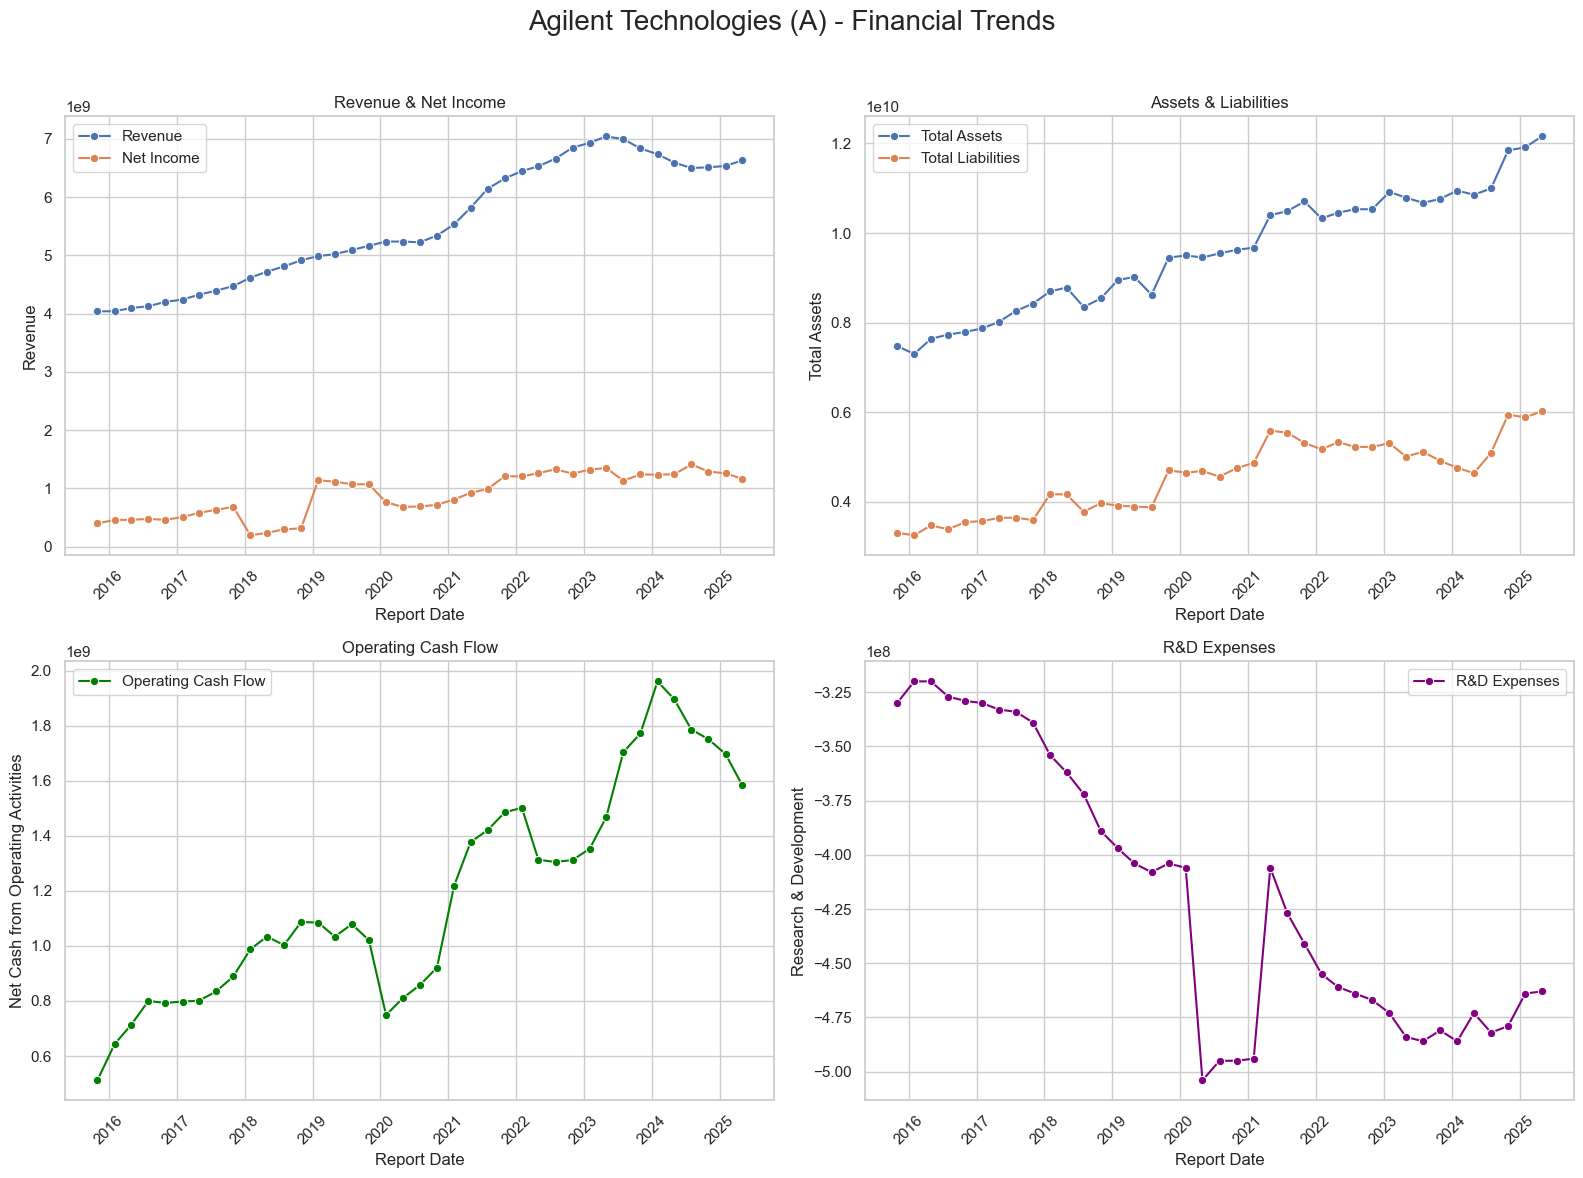

In [3]:
# --- 5. 单一公司趋势分析 (以 'A' 公司为例) ---
df_a = df_final[df_final['Ticker'] == 'A'].sort_values(by='Report Date').copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Agilent Technologies (A) - Financial Trends', fontsize=20)

sns.lineplot(data=df_a, x='Report Date', y='Revenue', ax=axes[0, 0], label='Revenue', marker='o')
sns.lineplot(data=df_a, x='Report Date', y='Net Income', ax=axes[0, 0], label='Net Income', marker='o')
axes[0, 0].set_title('Revenue & Net Income')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.lineplot(data=df_a, x='Report Date', y='Total Assets', ax=axes[0, 1], label='Total Assets', marker='o')
sns.lineplot(data=df_a, x='Report Date', y='Total Liabilities', ax=axes[0, 1], label='Total Liabilities', marker='o')
axes[0, 1].set_title('Assets & Liabilities')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.lineplot(data=df_a, x='Report Date', y='Net Cash from Operating Activities', ax=axes[1, 0], label='Operating Cash Flow', marker='o', color='green')
axes[1, 0].set_title('Operating Cash Flow')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.lineplot(data=df_a, x='Report Date', y='Research & Development', ax=axes[1, 1], label='R&D Expenses', marker='o', color='purple')
axes[1, 1].set_title('R&D Expenses')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [4]:
# --- 6. 计算并分析关键财务比率 ---
df_ratios = df_final.copy()
epsilon = 1e-6

df_ratios['Net Profit Margin'] = df_ratios['Net Income'] / (df_ratios['Revenue'] + epsilon)
df_ratios['ROA'] = df_ratios['Net Income'] / (df_ratios['Total Assets'] + epsilon)
df_ratios['ROE'] = df_ratios['Net Income'] / (df_ratios['Total Equity'] + epsilon)
df_ratios['Debt Ratio'] = df_ratios['Total Liabilities'] / (df_ratios['Total Assets'] + epsilon)
df_ratios['Current Ratio'] = df_ratios['Total Current Assets'] / (df_ratios['Total Current Liabilities'] + epsilon)

print("\n--- 'A'公司的财务比率 ---")
display(df_ratios[df_ratios['Ticker'] == 'A'][['Report Date', 'Net Profit Margin', 'ROE', 'Debt Ratio', 'Current Ratio']].tail())



--- 'A'公司的财务比率 ---


,Report Date,Net Profit Margin,ROE,Debt Ratio,Current Ratio
34,2024-04-30,0.188439,0.199871,0.427598,2.146578
35,2024-07-31,0.217485,0.239370,0.463168,1.781499
36,2024-10-31,0.198003,0.218549,0.502110,2.089182
37,2025-01-31,0.192714,0.208893,0.494125,2.197432
38,2025-04-30,0.175920,0.190026,0.495312,2.091451



--- 公司横向对比 (最新报告期) ---


,Ticker,Net Profit Margin,ROE,Debt Ratio,Current Ratio
38,A,0.175920,0.190026,0.495312,2.091451
73,AA,0.067904,0.145319,0.593934,1.713393


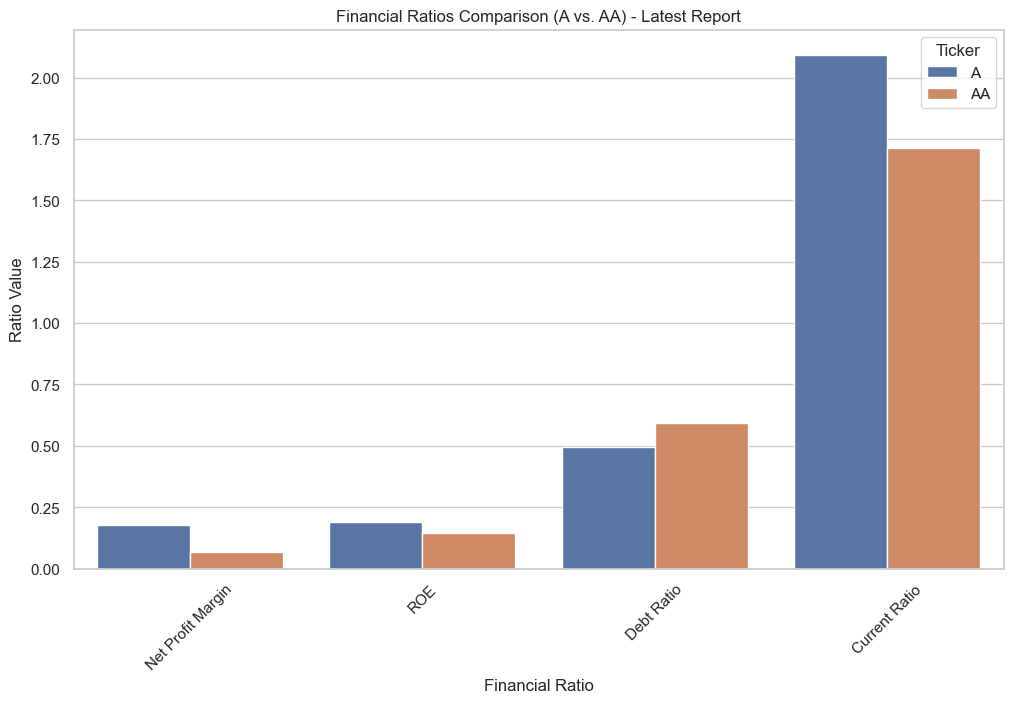

In [6]:
# --- 7. 跨公司横向对比 ---
latest_report = df_ratios.loc[df_ratios.groupby('Ticker')['Report Date'].idxmax()]
comparison_metrics = ['Net Profit Margin', 'ROE', 'Debt Ratio', 'Current Ratio']
comparison_df = latest_report[latest_report['Ticker'].isin(['A', 'AA'])][['Ticker'] + comparison_metrics]

print("\n--- 公司横向对比 (最新报告期) ---")
display(comparison_df)

comparison_df_melted = comparison_df.melt(id_vars='Ticker', var_name='Ratio', value_name='Value')

plt.figure(figsize=(12, 7))
sns.barplot(data=comparison_df_melted, x='Ratio', y='Value', hue='Ticker')
plt.title('Financial Ratios Comparison (A vs. AA) - Latest Report')
plt.ylabel('Ratio Value')
plt.xlabel('Financial Ratio')
plt.xticks(rotation=45)
plt.show()